In [13]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# CARGA DE DATOS
# ==========================================

df = pd.read_csv(
    "../../Datos/saber11_limpio_base.csv"
)

print(df.shape)

df.head()

(301723, 52)


,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_codigo_icfes,cole_depto_ubicacion,...,punt_global,anio,fami_personashogar_num,fami_cuartoshogar_num,fami_estratovivienda_num,estu_fechanacimiento_dt,edad,densidad_hogar,indice_tecnologico,indice_bienes_hogar
0,20194,sb11201940125751,urbano,no,a,academico,411769000127,411769000127,702142,bogota,...,310.0,2019,3.5,2,2,2002-11-14,16.1,1.750000,2,4
1,20194,sb11201940049452,urbano,no,a,academico,111279000168,111279000168,73031,bogota,...,217.0,2019,3.5,3,2,2000-02-13,18.9,1.166667,0,1
2,20194,sb11201940292128,urbano,no,a,academico,111279000966,111279000966,25163,bogota,...,261.0,2019,5.5,2,3,2001-10-16,17.2,2.750000,2,3
3,20194,sb11201940062240,urbano,no,a,academico,111001020095,111001020095,113043,bogota,...,289.0,2019,7.5,6,2,2002-05-20,16.6,1.250000,2,3
4,20194,sb11201940135822,urbano,no,a,tecnico/academico,111001013129,111001013129,90787,bogota,...,267.0,2019,1.5,1,3,2003-04-29,15.7,1.500000,2,2


In [14]:
# ==========================================
# REVISAR VARIABLES
# ==========================================

print(df.columns.tolist())

['periodo', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede', 'cole_codigo_icfes', 'cole_depto_ubicacion', 'cole_mcpio_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_nombre_establecimiento', 'cole_nombre_sede', 'cole_sede_principal', 'estu_depto_reside', 'estu_mcpio_reside', 'estu_depto_presentacion', 'estu_mcpio_presentacion', 'estu_estudiante', 'estu_fechanacimiento', 'estu_genero', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'desemp_ingles', 'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global', 'anio', 'fami_personashogar_num', 'fami_cuartoshogar_num', 'fami_estratovivienda_

In [15]:
# ==========================================
# DISTRIBUCIÓN VARIABLE OBJETIVO
# ==========================================

print(
    df["desemp_ingles"]
    .value_counts()
)

print(
    df["desemp_ingles"]
    .value_counts(normalize=True)
)

desemp_ingles
a1    98441
a-    82684
a2    60050
b1    41071
b+    19477
Name: count, dtype: int64
desemp_ingles
a1    0.326263
a-    0.274039
a2    0.199024
b1    0.136122
b+    0.064553
Name: proportion, dtype: float64


In [16]:
# ==========================================
# VARIABLES DEL ESTABLECIMIENTO EDUCATIVO
# ==========================================

variables_modelo = [

    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_caracter",
    "cole_depto_ubicacion",
    "cole_genero",
    "cole_jornada",
    "cole_naturaleza",
    "cole_sede_principal"
]

target = "desemp_ingles"

# dataset final
df_model = df[
    variables_modelo + [target]
].copy()

print(df_model.shape)

df_model.head()

(301723, 10)


,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,cole_naturaleza,cole_sede_principal,desemp_ingles
0,urbano,no,a,academico,bogota,mixto,unica,no oficial,si,b1
1,urbano,no,a,academico,bogota,mixto,manana,oficial,si,a-
2,urbano,no,a,academico,bogota,mixto,manana,oficial,si,a1
3,urbano,no,a,academico,bogota,mixto,manana,oficial,si,a1
4,urbano,no,a,tecnico/academico,bogota,mixto,tarde,oficial,si,a2


In [17]:
# ==========================================
# ELIMINAR NULOS
# ==========================================

df_model = df_model.dropna()

print(df_model.shape)

(301089, 10)


In [18]:
# ==========================================
# VARIABLES PREDICTORAS Y TARGET
# ==========================================

X = df_model[variables_modelo]

y = df_model[target]

print(X.shape)
print(y.shape)

(301089, 9)
(301089,)


In [19]:
X.dtypes

cole_area_ubicacion     object
cole_bilingue           object
cole_calendario         object
cole_caracter           object
cole_depto_ubicacion    object
cole_genero             object
cole_jornada            object
cole_naturaleza         object
cole_sede_principal     object
dtype: object

In [20]:
# ==========================================
# PREPROCESAMIENTO
# One Hot Encoding para variables categóricas
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Codificar variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases del target:")
print(label_encoder.classes_)

# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# One Hot Encoding
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

print("X_train:", X_train_encoded.shape)
print("X_test:", X_test_encoded.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Clases del target:
['a-' 'a1' 'a2' 'b+' 'b1']
X_train: (240871, 25)
X_test: (60218, 25)
y_train: (240871,)
y_test: (60218,)


In [21]:
# ==========================================
# RED NEURONAL - CLASIFICACIÓN MULTICLASE
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Número de clases
n_classes = len(label_encoder.classes_)

# Modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compilar modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history = model.fit(
    X_train_encoded,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\lunar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3876 - loss: 1.3070 - val_accuracy: 0.3933 - val_loss: 1.2932
Epoch 2/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3905 - loss: 1.2937 - val_accuracy: 0.3939 - val_loss: 1.2913
Epoch 3/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3936 - loss: 1.2920 - val_accuracy: 0.3899 - val_loss: 1.2909
Epoch 4/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3915 - loss: 1.2917 - val_accuracy: 0.3926 - val_loss: 1.2901
Epoch 5/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3930 - loss: 1.2912 - val_accuracy: 0.3896 - val_loss: 1.2898
Epoch 6/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3931 - loss: 1.2911 - val_accuracy: 0.3935 - val_loss: 1.2890
Epoch 7/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3938 - loss: 1.2910 - val_accuracy: 0.3936 - val_loss: 1.2892
Epoch 8/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3935 - loss: 1.2910 - val_accuracy: 0.

In [22]:
# ==========================================
# EVALUACIÓN DEL MODELO
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predicciones
y_pred_prob = model.predict(X_test_encoded)

# Clase predicha
y_pred = y_pred_prob.argmax(axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Reporte clasificación
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

1882/1882 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step
Accuracy: 0.3982198013882892

Classification Report:

              precision    recall  f1-score   support

          a-       0.52      0.27      0.36     16476
          a1       0.41      0.62      0.49     19644
          a2       0.28      0.38      0.32     11997
          b+       0.68      0.44      0.54      3893
          b1       0.38      0.14      0.20      8208

    accuracy                           0.40     60218
   macro avg       0.45      0.37      0.38     60218
weighted avg       0.43      0.40      0.38     60218



In [23]:
# ==========================================
# MODELO 2 - RED MÁS PROFUNDA
# ==========================================

model_2 = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_encoded.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train_encoded,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


c:\Users\lunar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1506/1506 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3884 - loss: 1.3016 - val_accuracy: 0.3883 - val_loss: 1.2941
Epoch 2/50
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3908 - loss: 1.2933 - val_accuracy: 0.3943 - val_loss: 1.2910
Epoch 3/50
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3926 - loss: 1.2921 - val_accuracy: 0.3941 - val_loss: 1.2911
Epoch 4/50
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3925 - loss: 1.2916 - val_accuracy: 0.3944 - val_loss: 1.2903
Epoch 5/50
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3936 - loss: 1.2914 - val_accuracy: 0.3952 - val_loss: 1.2906


In [24]:
# ==========================================
# EVALUACIÓN MODELO 2
# ==========================================

# Predicciones
y_pred_prob_2 = model_2.predict(X_test_encoded)

# Clase predicha
y_pred_2 = y_pred_prob_2.argmax(axis=1)

# Accuracy
accuracy_2 = accuracy_score(y_test, y_pred_2)

print("Accuracy modelo 2:", accuracy_2)

# Classification report
print("\nClassification Report Modelo 2:\n")

print(
    classification_report(
        y_test,
        y_pred_2,
        target_names=label_encoder.classes_
    )
)

1882/1882 ━━━━━━━━━━━━━━━━━━━━ 2s 803us/step
Accuracy modelo 2: 0.3873426550200937

Classification Report Modelo 2:

              precision    recall  f1-score   support

          a-       0.61      0.20      0.30     16476
          a1       0.40      0.67      0.50     19644
          a2       0.36      0.01      0.03     11997
          b+       0.68      0.44      0.54      3893
          b1       0.27      0.61      0.37      8208

    accuracy                           0.39     60218
   macro avg       0.46      0.39      0.35     60218
weighted avg       0.45      0.39      0.34     60218



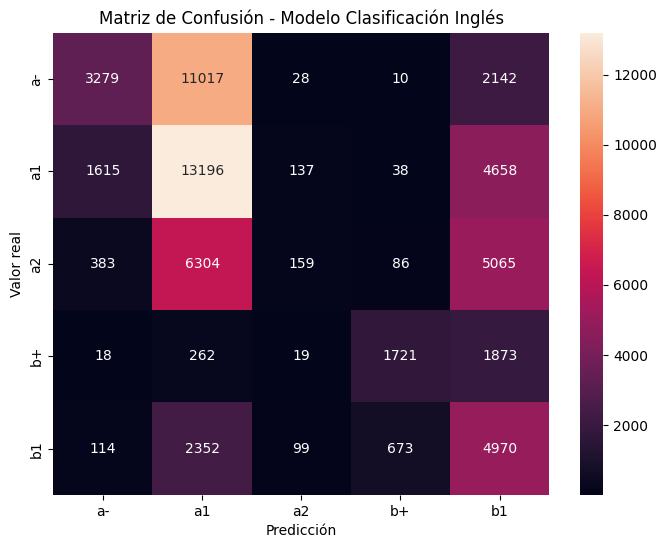

In [25]:
# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_2)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Modelo Clasificación Inglés")

plt.show()

In [26]:
# =====================================================
# RANDOM FOREST CLASSIFIER
# =====================================================

from sklearn.ensemble import RandomForestClassifier

# modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# entrenamiento
rf_model.fit(X_train_encoded, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [27]:
# =====================================================
# EVALUACIÓN RANDOM FOREST
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# predicción
y_pred_rf = rf_model.predict(X_test_encoded)

# accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy_rf)

# reporte clasificación
print("\nClassification Report Random Forest:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Accuracy Random Forest: 0.3984688963432861

Classification Report Random Forest:

              precision    recall  f1-score   support

          a-       0.52      0.27      0.36     16476
          a1       0.41      0.62      0.49     19644
          a2       0.28      0.38      0.32     11997
          b+       0.68      0.44      0.54      3893
          b1       0.38      0.14      0.20      8208

    accuracy                           0.40     60218
   macro avg       0.45      0.37      0.38     60218
weighted avg       0.43      0.40      0.38     60218



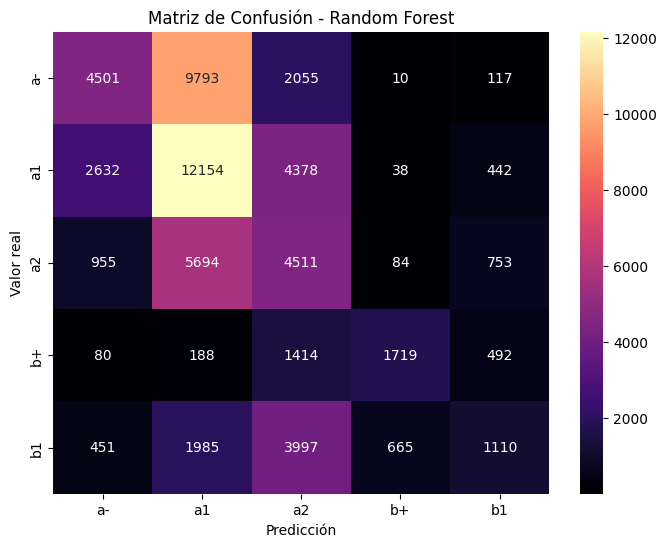

In [28]:
# =====================================================
# MATRIZ DE CONFUSIÓN RANDOM FOREST
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# gráfico
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Random Forest")

plt.show()

In [29]:
# =====================================================
# IMPORTANCIA DE VARIABLES
# =====================================================

import pandas as pd

# nombres variables después del One Hot Encoding
feature_names = encoder.get_feature_names_out(variables_modelo)

# importancia
feature_importance = pd.DataFrame({
    "variable": feature_names,
    "importance": rf_model.feature_importances_
})

# ordenar
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# top 15
top_variables = feature_importance.head(15)

top_variables

,variable,importance
15,cole_jornada_completa,0.254408
5,cole_calendario_b,0.119442
22,cole_naturaleza_oficial,0.090562
21,cole_naturaleza_no oficial,0.078892
4,cole_calendario_a,0.074511
17,cole_jornada_noche,0.074446
3,cole_bilingue_si,0.064526
2,cole_bilingue_no,0.050582
14,cole_genero_mixto,0.038238
18,cole_jornada_sabatina,0.030580


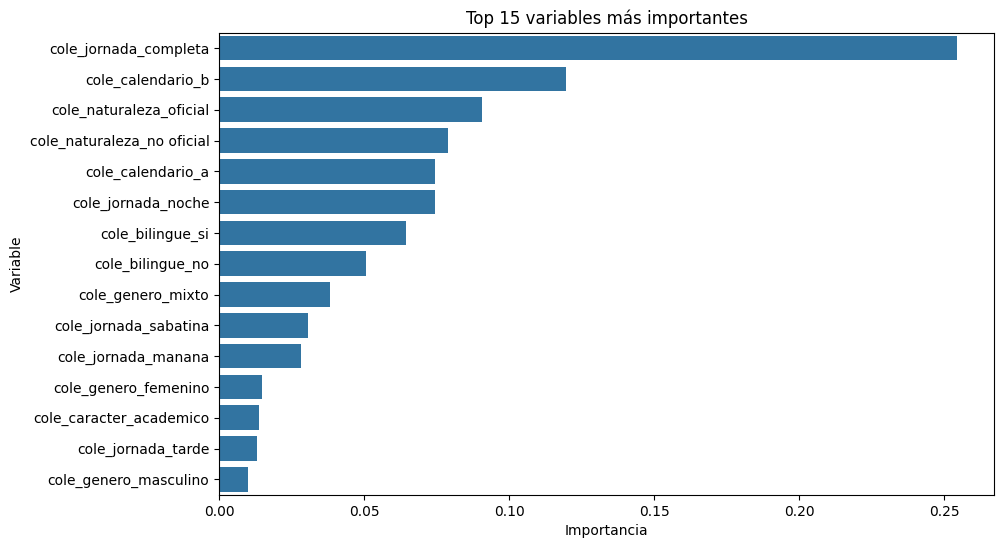

In [30]:
# =====================================================
# TOP VARIABLES MÁS IMPORTANTES
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_variables,
    x="importance",
    y="variable"
)

plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

In [31]:
# ==========================================
# COMPARACIÓN DE MODELOS
# ==========================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Red Neuronal",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "F1-score weighted": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

comparacion_modelos = comparacion_modelos.sort_values(
    by="F1-score weighted",
    ascending=False
)

comparacion_modelos

,Modelo,Accuracy,F1-score weighted
1,Random Forest,0.398469,0.383761
0,Red Neuronal,0.398220,0.383707


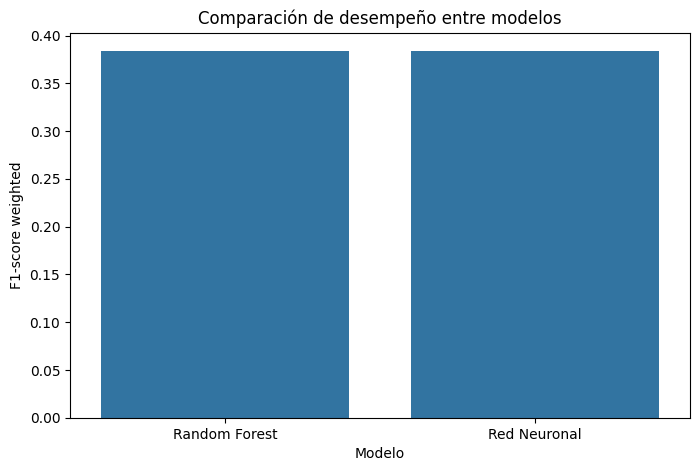

In [32]:
# ==========================================
# COMPARACIÓN VISUAL DE MODELOS
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion_modelos,
    x="Modelo",
    y="F1-score weighted"
)

plt.title("Comparación de desempeño entre modelos")
plt.ylabel("F1-score weighted")
plt.xlabel("Modelo")

plt.show()

In [34]:
import joblib

# guardar modelo Random Forest
joblib.dump(rf_model, "../../Despliegue/modelo_rf.pkl")

# guardar encoder
joblib.dump(encoder, "../../Despliegue/encoder.pkl")

print("Modelo y encoder guardados correctamente")

Modelo y encoder guardados correctamente
